# 1. EJEMPLO COMPARATIVO -> IRIS
El dataset Iris es un conjunto de datos que contiene información sobre flores del género Iris, concretamente de 3 especies:

- setosa
- versicolor
- virginica

Cada flor está descrita mediante 4 variables numéricas:

- Longitud del sépalo
- Anchura del sépalo
- Longitud del pétalo
- Anchura del pétalo

Y además tiene una etiqueta (la especie).
Puedes consultar más sobre este dataset en https://archive.ics.uci.edu/dataset/53/iris

En este notebook vamos a comparar dos enfoques distintos:

- un modelo de aprendizaje supervisado, que aprende usando etiquetas reales;
- un modelo K-Means, que agrupa observaciones sin conocer la especie.

La idea es comprobar que ambos pueden generar agrupaciones parecidas, pero no resuelven el mismo problema.

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 2. Cargar Iris

In [88]:
# Mantén este código. En él se carga el Dataset como un Objeto
iris = load_iris()

X = iris.data
y = iris.target

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)
print("Nombres de las clases:", iris.target_names)

df = pd.DataFrame(X, columns=iris.feature_names)
df["clase"] = y
df["nombre_clase"] = df["clase"].map({
    0: iris.target_names[0],
    1: iris.target_names[1],
    2: iris.target_names[2]
})

df.head()

Forma de X: (150, 4)
Forma de y: (150,)
Nombres de las clases: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),clase,nombre_clase
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## 2.1 Normalización

In [89]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Datos normalizados (primeras filas):")
print(X_scaled[:5])

Datos normalizados (primeras filas):
[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]


## 2.2 Método del Codo

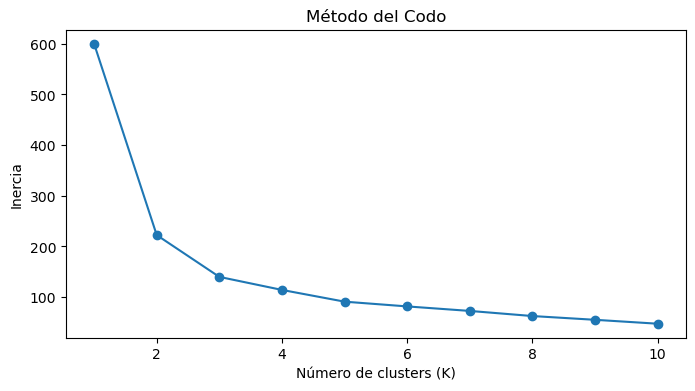

In [90]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inercia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled) # X_scaled es el dataset normalizado
    inercia.append(kmeans.inertia_)

plt.figure(figsize=(8,4))
plt.plot(range(1, 11), inercia, marker='o')
plt.title('Método del Codo')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Inercia')
plt.show()

# 3. Visualización sencilla de dos variables

Para representar el dataset de forma clara, vamos a usar dos variables:

- longitud del pétalo
- anchura del pétalo

Estas variables suelen separar mejor las especies que las medidas del sépalo.

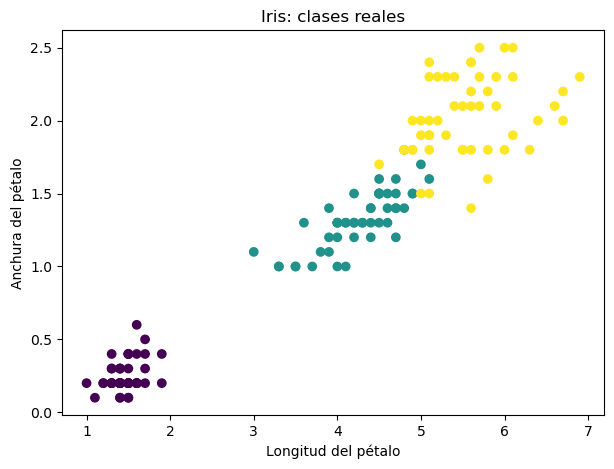

In [91]:
plt.figure(figsize=(7,5))
plt.scatter(X[:, 2], X[:, 3], c=y)
plt.xlabel("Longitud del pétalo")
plt.ylabel("Anchura del pétalo")
plt.title("Iris: clases reales")
plt.show()

# 4. Modelo Supervisado

## 4.1 Interpretación del modelo supervisado

En este caso, el modelo sí conoce las etiquetas reales durante el entrenamiento.

Por eso puede:

- aprender a distinguir especies;
- predecir la clase de nuevas flores;
- comparar sus predicciones con la realidad mediante métricas como la `accuracy` o la matriz de confusión.

0.9333333333333333


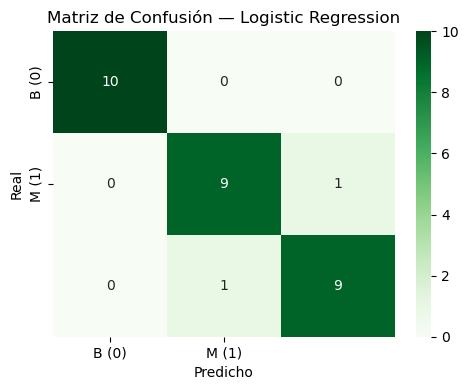

In [92]:
#
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size = 0.2, random_state = 42, stratify=y)

modelo_lr = LogisticRegression(max_iter=200, random_state=42)
modelo_lr.fit(X_train, y_train)

y_pred_lr = modelo_lr.predict(X_test)
print(accuracy_score(y_test, y_pred_lr))

# - matriz de confusión
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Greens",
            xticklabels=["B (0)", "M (1)"],
            yticklabels=["B (0)", "M (1)"])
plt.title("Matriz de Confusión — Logistic Regression")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

## 4.2 Visualización prediciones supervisadas

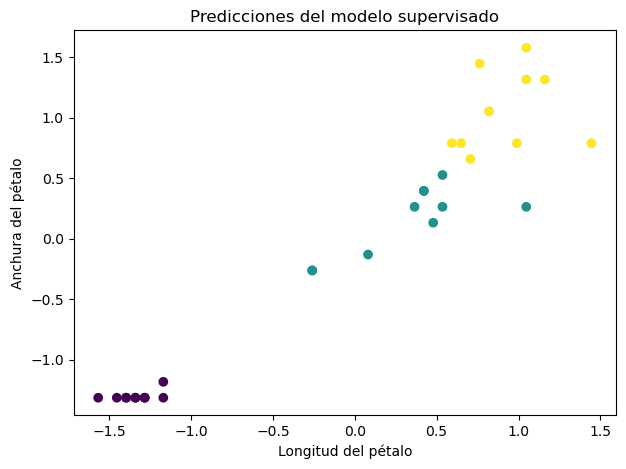

In [93]:
plt.figure(figsize=(7,5))
plt.scatter(X_test[:, 2], X_test[:, 3], c=y_pred_lr)
plt.xlabel("Longitud del pétalo")
plt.ylabel("Anchura del pétalo")
plt.title("Predicciones del modelo supervisado")
plt.show()

# 5. K-Means

Ahora aplicamos **K-Means** sobre el mismo conjunto de datos, pero sin utilizar las etiquetas reales.

Esto significa que el algoritmo:

- no sabe qué flor es setosa, versicolor o virginica;
- solo agrupa observaciones según su similitud.

Por tanto, los clusters obtenidos no tienen por qué coincidir exactamente con las clases reales.

In [94]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled)
clusters = kmeans.labels_


print("Primeros clusters asignados:", clusters[:20])
print("\nCentroides:")
print(kmeans.cluster_centers_)

Primeros clusters asignados: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

Centroides:
[[-0.05021989 -0.88337647  0.34773781  0.2815273 ]
 [-1.01457897  0.85326268 -1.30498732 -1.25489349]
 [ 1.13597027  0.08842168  0.99615451  1.01752612]]


In [95]:
# tengo que desnormalizar
X_original = scaler.inverse_transform(X)

## 5.1 Visualización K - Means

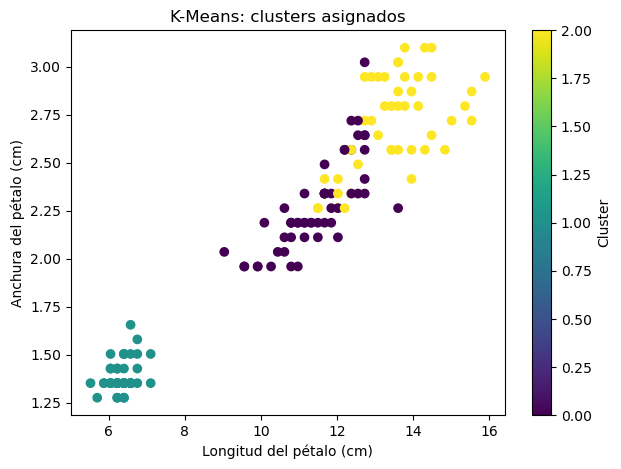

In [96]:

# tenemos que poder medir en cm. K-Means "ve" datos normalizados; sin emabrgo, estamos representando centímetros

plt.figure(figsize=(7, 5))
plt.scatter(X_original[:, 2], X_original[:, 3], c=clusters, cmap="viridis")
plt.xlabel("Longitud del pétalo (cm)")
plt.ylabel("Anchura del pétalo (cm)")
plt.title("K-Means: clusters asignados")
plt.colorbar(label="Cluster")
plt.show()


# 6. Comparación

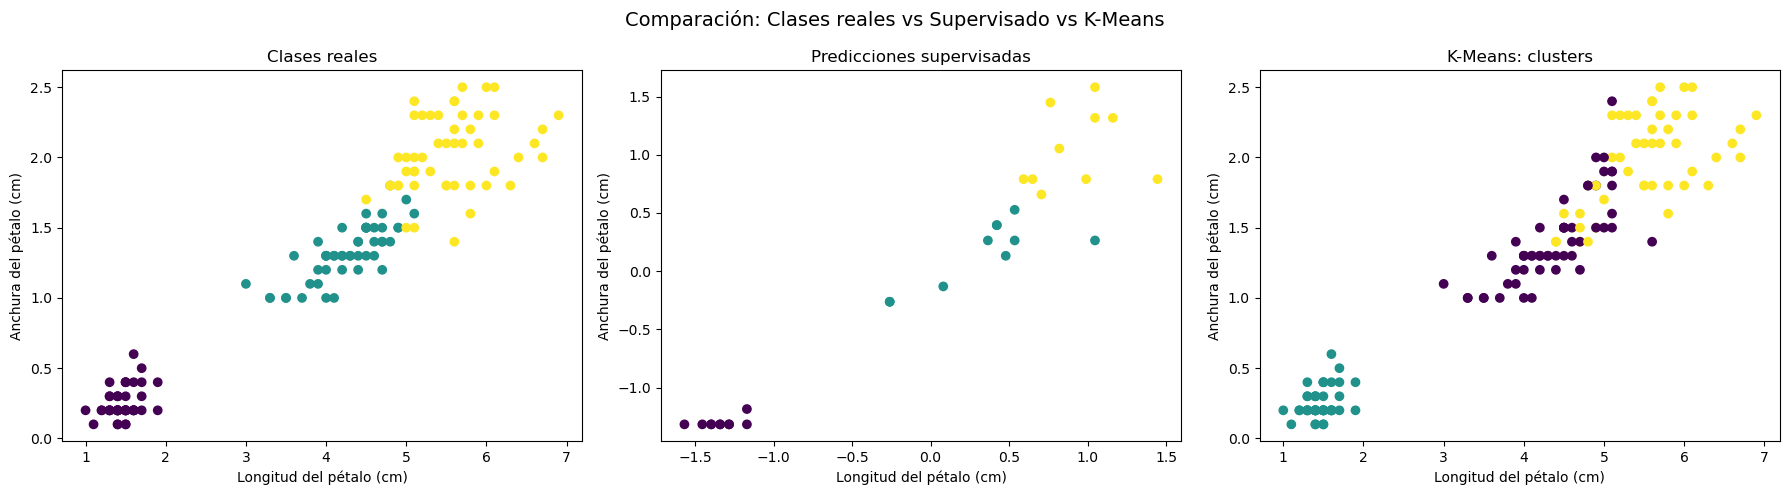

In [97]:
# gráficas que comparan todo lo visto hasta ahora
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfica 1: Clases reales
axes[0].scatter(X[:, 2], X[:, 3], c=y, cmap="viridis")
axes[0].set_title("Clases reales")
axes[0].set_xlabel("Longitud del pétalo (cm)")
axes[0].set_ylabel("Anchura del pétalo (cm)")

# Gráfica 2: Predicciones supervisadas (sobre test)
axes[1].scatter(X_test[:, 2], X_test[:, 3], c=y_pred_lr, cmap="viridis")
axes[1].set_title("Predicciones supervisadas")
axes[1].set_xlabel("Longitud del pétalo (cm)")
axes[1].set_ylabel("Anchura del pétalo (cm)")

# Gráfica 3: Clusters K-Means
X_original = scaler.inverse_transform(X_scaled)
axes[2].scatter(X_original[:, 2], X_original[:, 3], c=clusters, cmap="viridis")
axes[2].set_title("K-Means: clusters")
axes[2].set_xlabel("Longitud del pétalo (cm)")
axes[2].set_ylabel("Anchura del pétalo (cm)")

plt.suptitle("Comparación: Clases reales vs Supervisado vs K-Means", fontsize=14)
plt.tight_layout()
plt.show()


# 7. Comparación entre clases reales y clusters

La siguiente tabla permite comparar:

- las clases reales del dataset Iris;
- los grupos generados por K-Means.

Importante:
los números de los clusters no representan directamente las especies.
Por ejemplo, el cluster 0 no tiene por qué corresponder a la clase 0.

Esta tabla sirve para ver qué especies quedan mejor agrupadas y cuáles se mezclan más.

In [98]:
#pon el código aquí
import pandas as pd
from sklearn.metrics import adjusted_rand_score

# Tabla comparativa
df_comparacion = pd.DataFrame({
    "Clase real": y,
    "Cluster K-Means": clusters
})

# Tabla cruzada: cuántas flores de cada clase cayeron en cada cluster
tabla_cruzada = pd.crosstab(
    df_comparacion["Clase real"],
    df_comparacion["Cluster K-Means"],
    rownames=["Clase real"],
    colnames=["Cluster K-Means"]
)

# Renombrar filas para más claridad
tabla_cruzada.index = iris.target_names

print("=== TABLA CRUZADA: Clases reales vs Clusters ===")
print(tabla_cruzada)

# Métrica de similitud (no requiere alinear etiquetas manualmente)
ari = adjusted_rand_score(y, clusters)
print(f"\nAdjusted Rand Index: {ari:.4f}")
print("(1.0 = perfecto, 0.0 = aleatorio)")

=== TABLA CRUZADA: Clases reales vs Clusters ===
Cluster K-Means   0   1   2
setosa            0  50   0
versicolor       39   0  11
virginica        14   0  36

Adjusted Rand Index: 0.6201
(1.0 = perfecto, 0.0 = aleatorio)


# 8. Conclusiones

- El modelo supervisado aprende usando etiquetas reales.
- K-Means no utiliza etiquetas, solo busca agrupaciones por similitud.
- En el dataset Iris, la especie setosa suele quedar muy bien separada.
- Versicolor y virginica presentan más similitud y pueden mezclarse más.
- Un cluster no equivale necesariamente a una clase real.
- otras...

# 9. Cuestiones

1. ¿Por qué el modelo supervisado puede calcular su `accuracy`?
    -   El modelo supervisado puede calcular la accuracy ya que los datos estan etiquetados, al tener los datos etiquetados podemos hacer una prediccion, lo que
        nos lleva a obtener un resultado llamado accuracy.

2. ¿Por qué **K-Means** no puede compararse directamente con las clases reales usando solo los números de cluster?
    -   Porque K-Means pone nombres a sus grupos de forma aleatoria (0, 1, 2...). El grupo que él llama "0" puede ser el que tú llamas "setosa", o puede no serlo.

3. ¿Qué especie parece separarse mejor en el dataset Iris?
    -   Setosa ya que en la grafica se ve claramente apartada de las otras dos. Versicolor y virginica se mezclan un poco entre ellas.

4. ¿Qué diferencias observas entre clasificar y agrupar?
    -   Al agrupar, puede cometer errores ya que los datos de este dataset estan etiquetados, entonces al clasficar seria mas preciso que agrupar.

5. ¿En qué casos reales tendría sentido usar un modelo supervisado y en cuáles **K-Means**?
    -   Usar el modelo supervisado cuando tienes datos con etiquetas: detectar spam, diagnosticar enfermedades, reconocer imágenes.
        Usar K-Means cuando no tienes etiquetas y quieres descubrir grupos: segmentar clientes, agrupar noticias, analizar comportamientos.
